# Experiment 2: Training Dynamics and Hedge Quality

This notebook investigates how different training configurations affect the quality of Snowball hedging. We'll compare various training epoch schedules and analyze the convergence behavior.

## Objectives
- Compare different training epoch schedules
- Analyze hedger price convergence
- Examine PnL distributions at different training stages
- Understand the impact of training duration on hedge quality

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt

# PfHedge imports
from pfhedge.instruments import BrownianStock, Snowball
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import EntropicRiskMeasure
from pfhedge.nn.modules.mlp import MultiLayerPerceptron

# Set random seed for reproducibility
torch.manual_seed(42)
print("Training dynamics experiment loaded successfully!")

Training dynamics experiment loaded successfully!


In [2]:
def create_basic_snowball():
    """Create a basic Snowball option for experimentation."""

    # Market parameters
    init_state = 100.0
    dt = 1 / 250  # Daily time steps
    sigma = 0.2
    mu = 0.0
    cost = 1e-4

    # Underlying stock
    stock = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=cost)

    # Observation dates (monthly observations over 1 year)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]

    # Snowball parameters
    derivative = Snowball(
        underlier=stock,
        notional=1.0,
        init_spot=init_state,
        strike=100.0,
        maturity=obs_days[-1] * dt,
        knockin_barrier=80.0,  # 20% below initial spot
        observations=[d * dt for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),  # At-the-money knock-out
        knockout_coupons=[0.5 * d / 250 for d in obs_days],  # Time-proportional coupons
        no_touch_coupon=0.05,  # 5% if never knocked out
        is_knocked_in=False,
    )

    return derivative, stock, init_state

Training Dynamics Experiment
Training hedger with progressive snapshots...


Loss=0.0519: 100%|██████████| 100/100 [03:34<00:00,  2.15s/it]



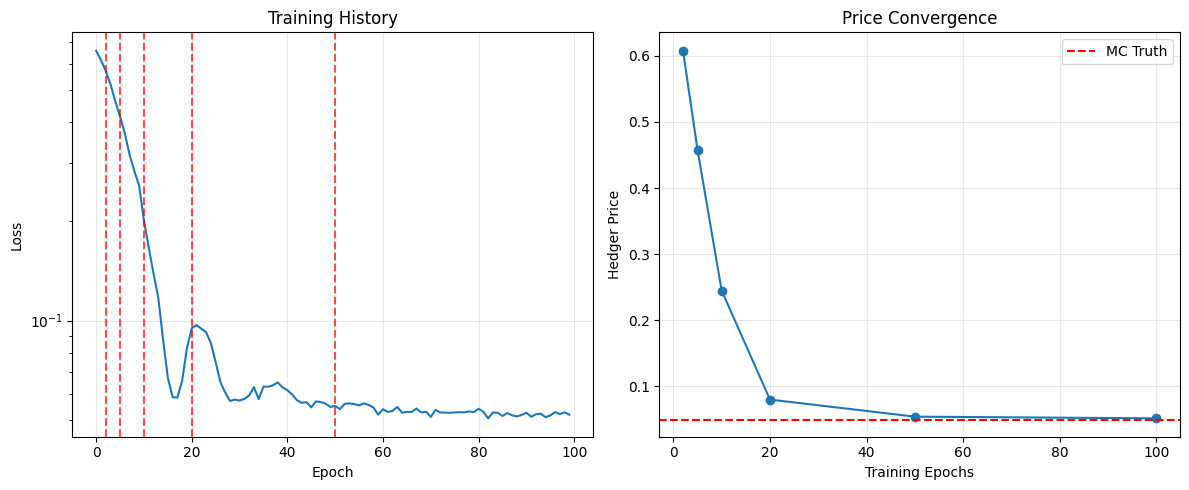


PnL Distribution Analysis:
------------------------------
2 epochs - Mean PnL: -0.061423, Std PnL: 1.492943
5 epochs - Mean PnL: -0.059586, Std PnL: 1.219828
10 epochs - Mean PnL: -0.056513, Std PnL: 0.764692
20 epochs - Mean PnL: -0.050895, Std PnL: 0.231024
2 epochs - Mean PnL: -0.061423, Std PnL: 1.492943
5 epochs - Mean PnL: -0.059586, Std PnL: 1.219828
10 epochs - Mean PnL: -0.056513, Std PnL: 0.764692
20 epochs - Mean PnL: -0.050895, Std PnL: 0.231024
50 epochs - Mean PnL: -0.051047, Std PnL: 0.103831
100 epochs - Mean PnL: -0.050836, Std PnL: 0.060848
50 epochs - Mean PnL: -0.051047, Std PnL: 0.103831
100 epochs - Mean PnL: -0.050836, Std PnL: 0.060848


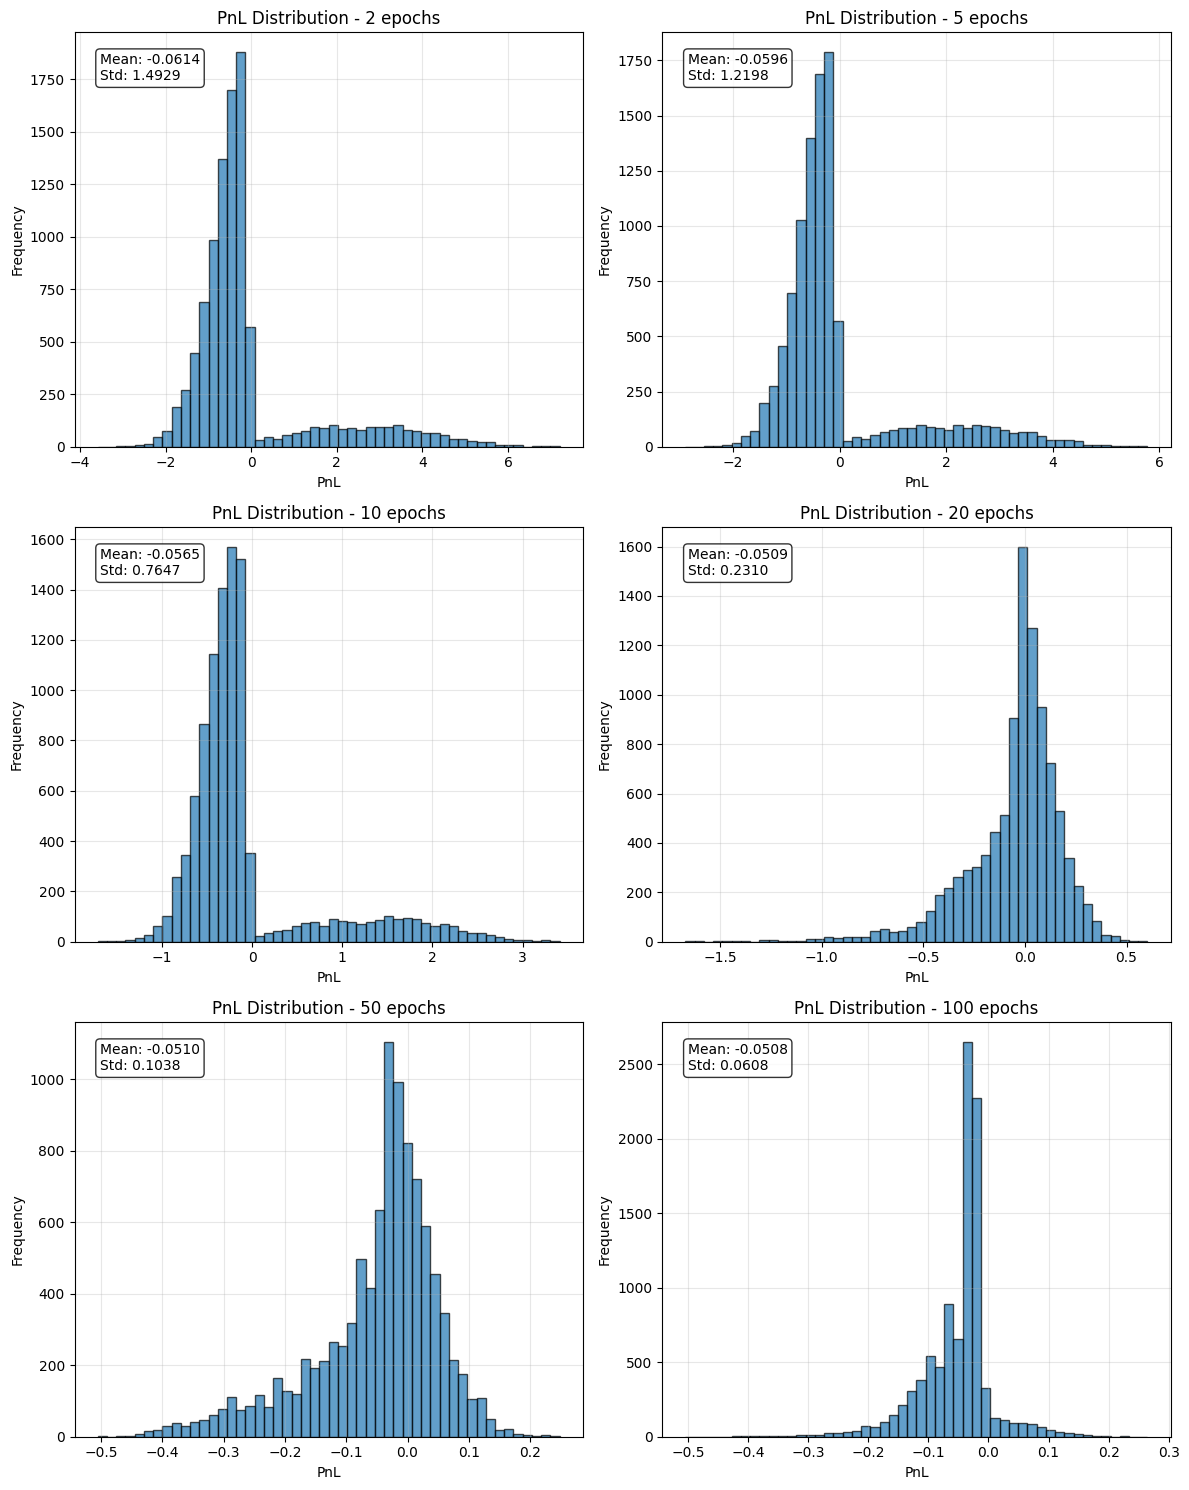

In [3]:
def training_dynamics_experiment():
    """Experiment with different training dynamics for Snowball hedging."""

    print("Training Dynamics Experiment")
    print("=" * 50)

    # Create derivative
    derivative, stock, init_state = create_basic_snowball()

    # Training parameters
    fit_n_paths = 10000
    fit_n_epochs = [2, 5, 10, 20, 50, 100]
    loss = EntropicRiskMeasure(a=1)

    # Features for Snowball hedging
    features = [
        "log_moneyness",     # Current underlying price relative to strike
        "expiry_time",       # Time to expiration
        "volatility",        # Implied volatility
        "knocked_in",        # Whether barrier has been touched
        "prev_hedge"         # Previous hedge position
    ]

    # Create hedger
    hedger = Hedger(
        MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
        features,
        criterion=loss,
    )

    # Fit hedger with snapshots
    init_spot = torch.tensor(init_state, requires_grad=True)

    print("Training hedger with progressive snapshots...")
    history, hedgers = hedger.fit(
        derivative,
        n_epochs=fit_n_epochs[-1],
        n_paths=fit_n_paths,
        init_state=(init_spot,),
        snapshots=fit_n_epochs[:-1],
    )

    # Get baseline PV for comparison
    # Quick valuation
    derivative.simulate(n_paths=100000, init_state=(init_spot,))
    pv_basic = derivative.payoff().mean().item()

    # Plot training history
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training History")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

    # Mark snapshot points
    for epoch in fit_n_epochs[:-1]:
        plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7)

    # Evaluate hedger price at different training stages
    prices = []
    for h in hedgers:
        price = h.price(derivative, n_paths=50000, init_state=(init_spot,))
        prices.append(price.item())

    plt.subplot(1, 2, 2)
    plt.plot(fit_n_epochs, prices, 'o-')
    plt.axhline(y=pv_basic, color='red', linestyle='--', label='MC Truth')
    plt.xlabel("Training Epochs")
    plt.ylabel("Hedger Price")
    plt.title("Price Convergence")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Analyze PnL distributions
    print("\nPnL Distribution Analysis:")
    print("-" * 30)

    # Test PnL for different training stages
    derivative.simulate(n_paths=fit_n_paths, init_state=(init_spot,))
    pnls = [h.compute_pl(derivative) for h in hedgers]

    # Plot PnL distributions
    n_row = (len(pnls) + 1) // 2
    fig, axes = plt.subplots(n_row, 2, figsize=(12, 5 * n_row))
    axes = axes.flatten() if n_row > 1 else [axes] if n_row == 1 else axes

    for i, (pnl, epochs) in enumerate(zip(pnls, fit_n_epochs)):
        ax = axes[i]
        ax.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
        ax.set_xlabel("PnL")
        ax.set_ylabel("Frequency")
        ax.set_title(f"PnL Distribution - {epochs} epochs")
        ax.grid(True, alpha=0.3)

        # Add statistics
        mean_pnl = pnl.mean().item()
        std_pnl = pnl.std().item()
        ax.text(0.05, 0.95, f'Mean: {mean_pnl:.4f}\nStd: {std_pnl:.4f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        print(f"{epochs} epochs - Mean PnL: {mean_pnl:.6f}, Std PnL: {std_pnl:.6f}")

    # Hide empty subplots
    for i in range(len(pnls), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

    return hedgers, history

# Run training dynamics experiment
hedgers_basic, history_basic = training_dynamics_experiment()

## Key Insights from Training Dynamics

### Training Convergence
- **Loss Reduction**: Progressive improvement in hedging loss with more epochs
- **Price Convergence**: Hedger prices approach Monte Carlo truth with training
- **Diminishing Returns**: Benefits plateau after certain training duration

### PnL Distribution Evolution
- **Risk Reduction**: Standard deviation of PnL decreases with training
- **Mean Centering**: PnL distributions become more centered around zero
- **Shape Changes**: Distributions become more concentrated with training

### Practical Implications
- **Training Budget**: Balance between training time and hedge quality
- **Early Stopping**: Monitor convergence to avoid overtraining
- **Performance Metrics**: Use both loss and PnL statistics for evaluation

This experiment demonstrates the importance of adequate training for complex derivatives like Snowball options, where path-dependent features require sophisticated learning strategies.